# Debiasing Word Embeddings

### What are Word Embeddings?

Word Embeddings are the result of applying dimensionality reduction techniques to words!

They give us dense representations of words, which we hope capture some of their syntactic and semantic information. These dense representations are a natural tool for passing words into neural models, and the field of Natural Language Processing (NLP) has used variants of word embeddings extensively.

There are many, many, many ways to build word embeddings, but the key intuition comes from the notion that the meaning of a word can be inferred from the types of words it appears next to, or as put by John Firth in 1975: "You shall know a word by the company it keeps".

Typically, we start with a large corpus of text. We'll use this corpus to give us counts of words that occur next to each other, which is a pretty good start. In this matrix, our rows correspond to an "embedding" of sorts, where each word's embedding is a word-by-word count of the words that appear next to it.

It's a hyperparameter to choose how large a window you use when considering words "next to each other", or if you want to do clever things, like weight each word by how distant it is from the word you're looking at.

Here's what a word co-occurrence matrix looks like:
<img src="figs/word-co-occurrence.png" alt="Drawing" style="width: 600px;"/>

<a style="font-size:9pt" href="http://web.stanford.edu/class/cs224u/materials/cs224u-vsm-overview.pdf">source</a>

Each row now captures _something_ about the word it represents, in that words that appear in similar contexts will be closer together. Of course, they might not actually be _that_ close together, since our space is the size of our vocabulary.

How big is our Vocabulary? Well, that's another hyperparameter. 
You can decide to filter out words that don't occur that often, to potentially get rid of noise, etc. 
But generally, it's going to be close to 300K or 400K. That means our word vectors are of dimension 400,000! Luckily, we can use dimensionality reduction techniques, such as those you've seen already, to learn a low-dimensional representation of this co-occurrence matrix. This will give us low-dimensional (200-300d), dense word vectors to use, so we can operate over them efficiently and pass them into models such as neural networks!

GloVe (Global Vectors for Word Representations https://nlp.stanford.edu/projects/glove/).

In [1]:
import numpy as np
from numpy.linalg import norm
from arsenal import Alphabet
from embedding import Embeddings, normalize_rows, load_vecs

In [2]:
with np.load('vecs.npz') as data:
    glove_vecs = data['vec']
    glove_ix = data['voc']

In [3]:
emb = Embeddings(normalize_rows(glove_vecs), Alphabet(glove_ix))
analogy = emb.analogy

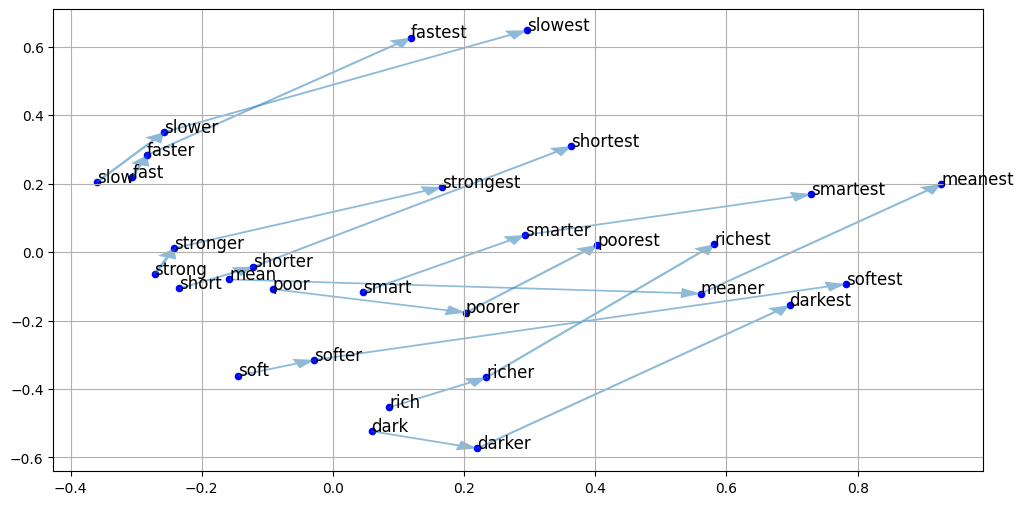

In [4]:
superlatives = """
poor   poorer   poorest
rich   richer   richest
short  shorter  shortest
slow   slower   slowest
fast   faster   fastest
soft   softer   softest
strong stronger strongest
mean   meaner   meanest
dark   darker   darkest
smart  smarter  smartest
"""

emb.plot_paths(superlatives)

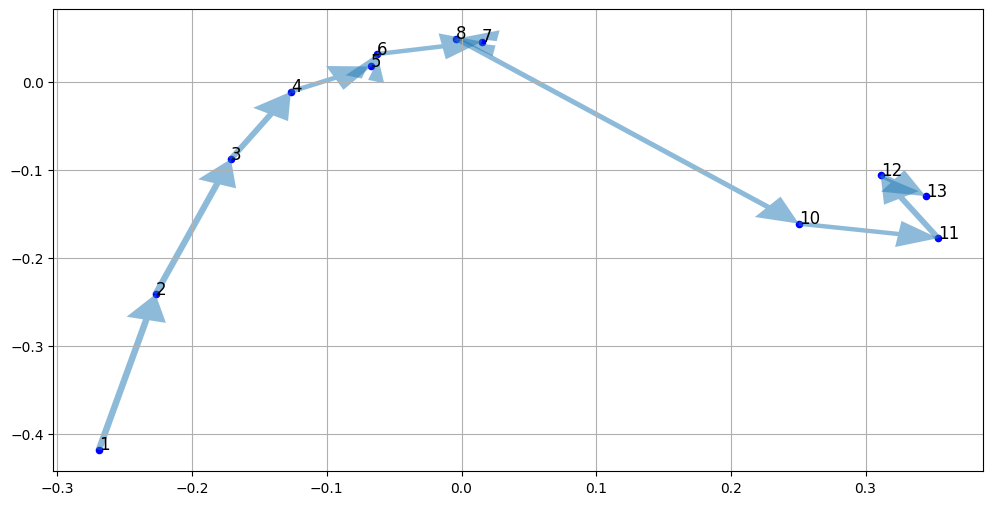

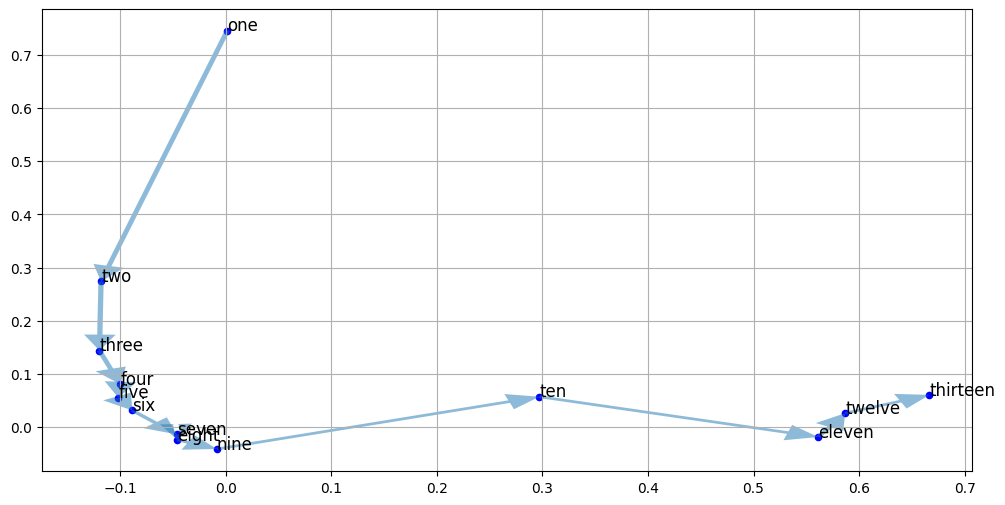

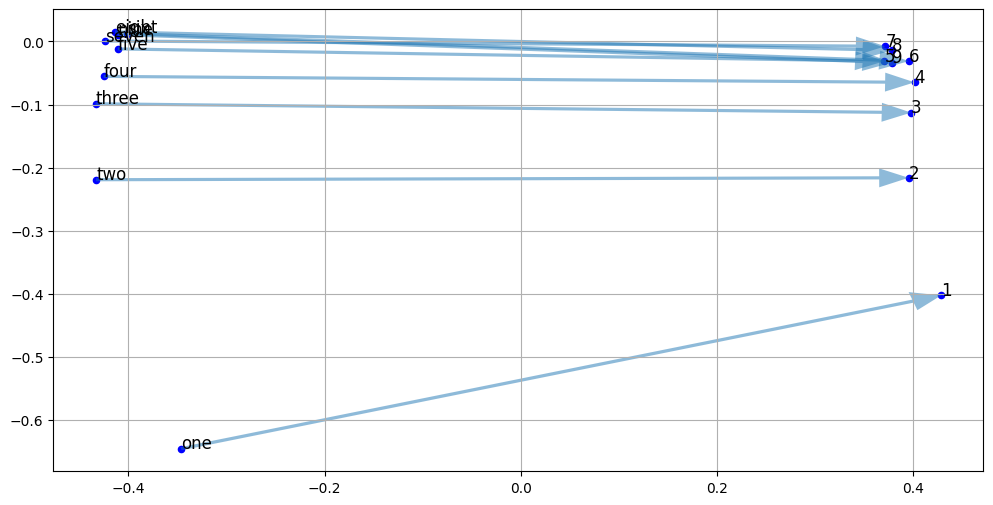

In [5]:
emb.plot_paths("""
1 2 3 4 5 6 7 8 10 11 12 13
""")

emb.plot_paths("""
one two three four five six seven eight nine ten eleven twelve thirteen
""")

emb.plot_paths("""
one 1
two 2
three 3
four 4
five 5
six 6
seven 7
eight 8
nine 9
""")

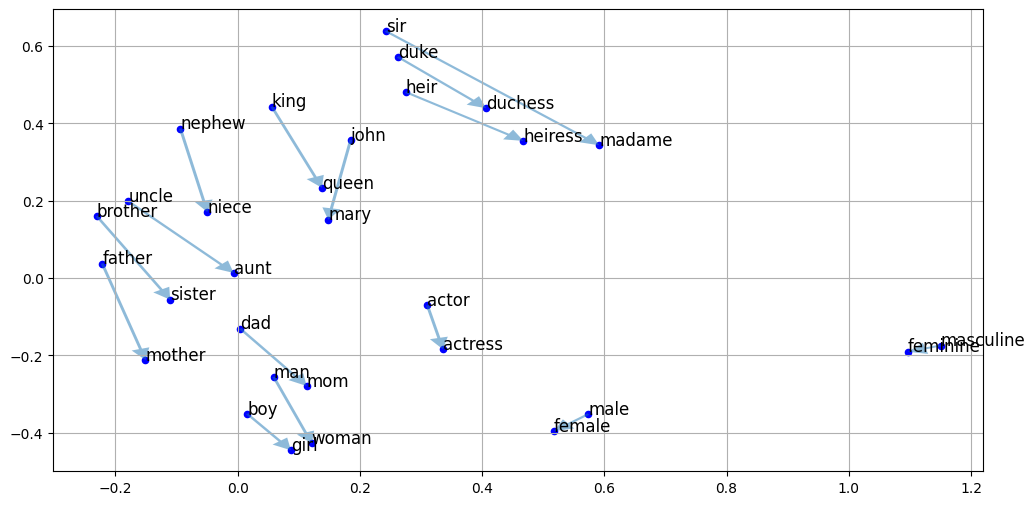

In [6]:
gendered = """
man   woman
king  queen
actor actress
boy   girl
dad   mom
father mother
john mary
brother sister
uncle aunt
heir heiress
duke duchess
nephew niece
sir madame
# count countess
male female
masculine feminine
"""

emb.plot_paths(gendered)

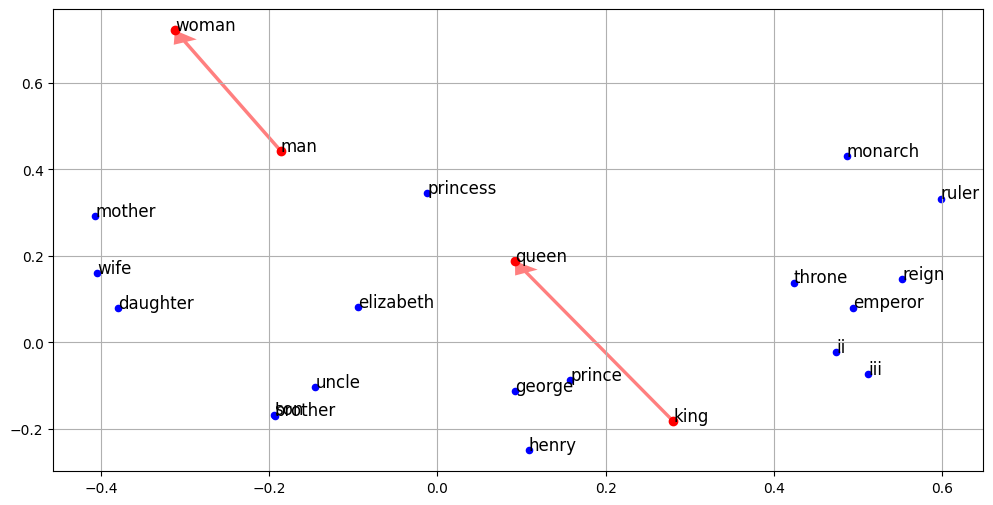

In [7]:
emb.plot_analogy('man', 'woman', 'king', n=10)

Somewhat importantly, there seems to be some notion of semantics captured in the _vector difference_ between two words. This led to the very popular "analogy" game, where it was found you could take the difference of two vectors, add it to another vector, and get this sort of analogy of the first two, compared to the second.

The canonical example here is "Man is to King as Woman is to"... And it turns out, when you use GloVe word embeddings to do this task, you get "Queen"! Which is pretty cool!

Here are some examples of the embedding space, and you can kind of see why this works!

The distance between man and woman and king and queen looks similar, but so does the direction! So it makes sense that the vector difference between woman and man, added to king, looks like queen.

Remember that the analogy intuition comes from that $w_1 - w_2 \approx w_3 - w_4$, so your function should be searching for vectors which are similar to $w_4 \approx w_2 - w_1 + w_3$!

In [8]:
emb.analogy('man :: woman -> john')
emb.analogy('man :: woman -> peter')
emb.analogy('man :: woman -> michael')
emb.analogy('man :: woman -> paul')
emb.analogy('man :: woman -> tim')
emb.analogy('man :: woman -> timothy')

emb.analogy('woman :: man -> rachael')
emb.analogy('woman :: man -> hanna')
emb.analogy('woman :: man -> hannah')

man :: woman -> john :: [mary]
man :: woman -> peter :: [mary]
man :: woman -> michael :: [susan]
man :: woman -> paul :: [mary]
man :: woman -> tim :: [greg]
man :: woman -> timothy :: [kathleen]
woman :: man -> rachael :: [louie]
woman :: man -> hanna :: [ike]
woman :: man -> hannah :: [miley]


In [9]:
analogy("man :: fraternity -> woman")
analogy("man :: king -> woman")
analogy("man :: prince -> woman")
analogy("man :: boy -> woman")
analogy("man :: ass -> woman")
analogy("man :: dick -> woman")
analogy("man :: prick -> woman")
analogy("man :: bastard -> woman")
analogy("man :: dad -> woman")
analogy("man :: grandpa -> woman")
analogy("man :: uncle -> woman")
analogy("man :: dog -> woman")
analogy("man :: boy -> woman")

man :: fraternity -> woman :: [sorority]
man :: king -> woman :: [queen]
man :: prince -> woman :: [princess]
man :: boy -> woman :: [girl]
man :: ass -> woman :: [bitch]
man :: dick -> woman :: [gephardt]
man :: prick -> woman :: [pricked]
man :: bastard -> woman :: [bitch]
man :: dad -> woman :: [mom]
man :: grandpa -> woman :: [grandma]
man :: uncle -> woman :: [aunt]
man :: dog -> woman :: [cat]
man :: boy -> woman :: [girl]


### (Gender) Bias in Word Embeddings

Word embeddings are a very useful tool in NLP, and they have often helped researchers boost their performance in a variety of tasks. However, recently a large problem has been discovered in these types of word embeddings. They inherit some biases from the data they are trained on which is very harmful, such as mysoginistic or racist stereotypes. This is a **huge** problem, because models which use these embeddings are being deployed into the real word to assist with automation strategies!

Let's take a look at some examples of gender bias in our word embeddings, which we'll be focusing on for the rest of this assignment.

In [10]:
#analogy("man :: woman -> career")
analogy("man :: woman -> programmer")
analogy("man :: woman -> engineer")
analogy("man :: woman -> doctor")
analogy("man :: professor -> woman")
analogy("man :: woman -> teacher")
analogy("man :: woman -> athlete")
analogy("man :: woman -> baseball")
analogy("man :: hockey -> woman")
analogy("man :: basketball -> woman")
analogy("man :: golf -> woman")
analogy("man :: tennis -> woman")
analogy("man :: volleyball -> woman")
analogy("man :: softball -> woman")
analogy("woman :: man -> menstruating")

# Even names contain these biases!
analogy("john :: mary -> doctor")

man :: woman -> programmer :: [educator]
man :: woman -> engineer :: [technician]
man :: woman -> doctor :: [nurse]
man :: professor -> woman :: [sociology]
man :: woman -> teacher :: [student]
man :: woman -> athlete :: [swimmer]
man :: woman -> baseball :: [softball]
man :: hockey -> woman :: [basketball]
man :: basketball -> woman :: [softball]
man :: golf -> woman :: [tennis]
man :: tennis -> woman :: [volleyball]
man :: volleyball -> woman :: [softball]
man :: softball -> woman :: [volleyball]
woman :: man -> menstruating :: [ogling]
john :: mary -> doctor :: [nurse]


In [11]:
gender_pairs = """
she he 
woman man
herself himself
her him
hers his
gal guy
girl boy
girls boys
female male 
females males
girls guys
girl guy
#queen king
#masseuse masseur
#daughter son
#sister brother
#mother father
#aunt uncle
#actress actor
"""

deb = emb.debias(gender_pairs, K = 10)

In [12]:
# Biggest changes
diff = norm(emb.vec - deb.vec, axis=1)
top = np.argsort(-diff)
for i in top[:5]:
    w = emb.dom.lookup(i)
    print(diff[i], w)

0.7944460816863458 menstruating
0.7715366876836688 gal
0.7711837913461759 guy
0.7708127801264693 girl
0.7676520401296967 boy


We'll only implement the neutralize" portion of the hard-debiasing method in the paper, if you're following along.
We won't implement equalize or the Soft-Debiasing method, to keep things short :)

Once we have our gender subspace $\mathcal{B}$ composed of our $k$ orthogonal vectors, we can select some choice word $w$ to debias as follows:

1. Select the embedding $\vec{w}$ of word $w$ from our regular, biased embeddings.

2. Compute $$\vec{w_\mathcal{B}} = \sum_{j=i}^k (\vec{w} \cdot \vec{b_j}) * \vec{b_j}$$.

3. Compute the new, unbiased embedding as $$\vec{w_{ub}} = (\vec{w} - \vec{w_{\mathcal{B}}}) \; / \; || \vec{w} - \vec{w_{\mathcal{B}}} || $$

Intuitively, what we are doing is projecting our biased vector $\vec{w}$ into our gender subspace, and then subtracting the result from $\vec{w}$.

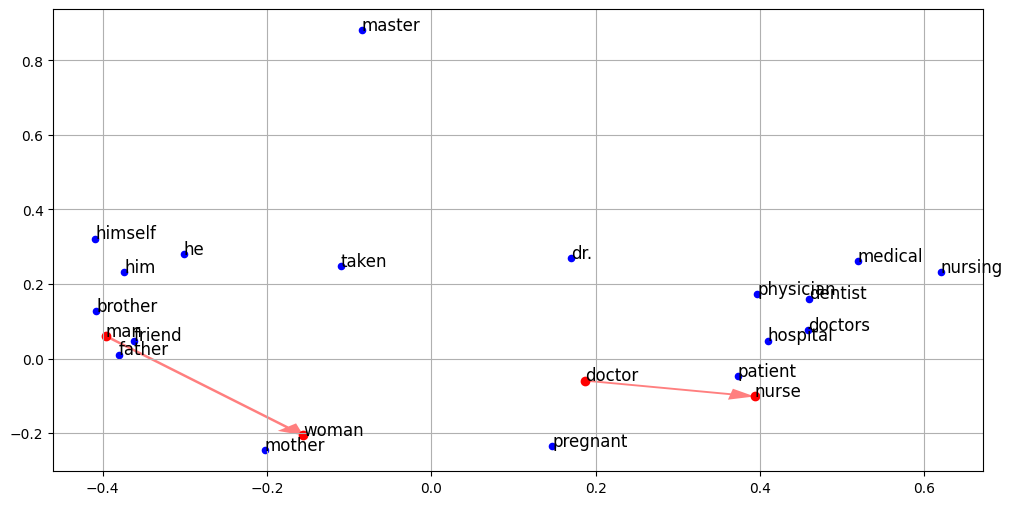

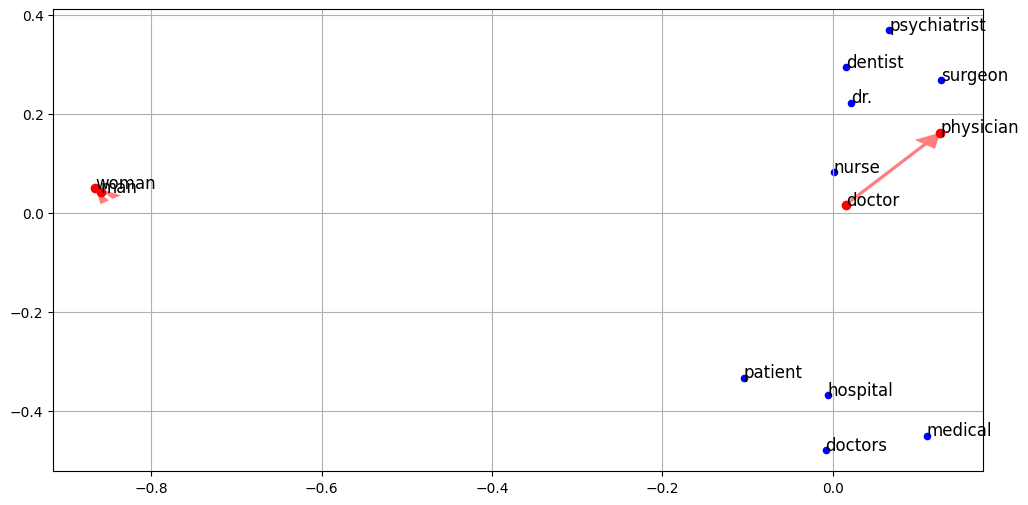

In [13]:
emb.plot_analogy('man', 'woman', 'doctor', n=10)
deb.plot_analogy('man', 'woman', 'doctor', n=10)

In [14]:
deb.analogy("man :: woman -> doctor")
deb.analogy("woman :: man -> doctor")

man :: woman -> doctor :: [physician]
woman :: man -> doctor :: [physician]


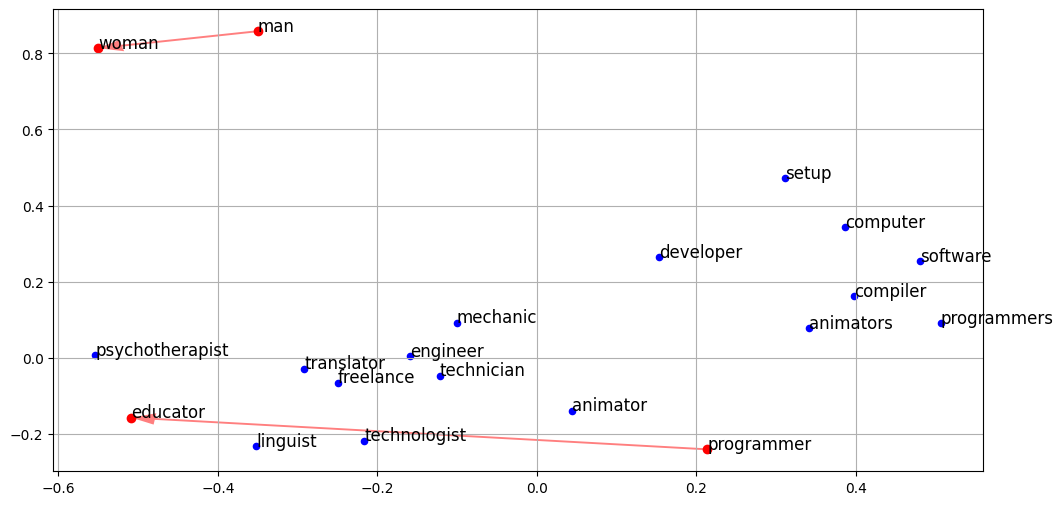

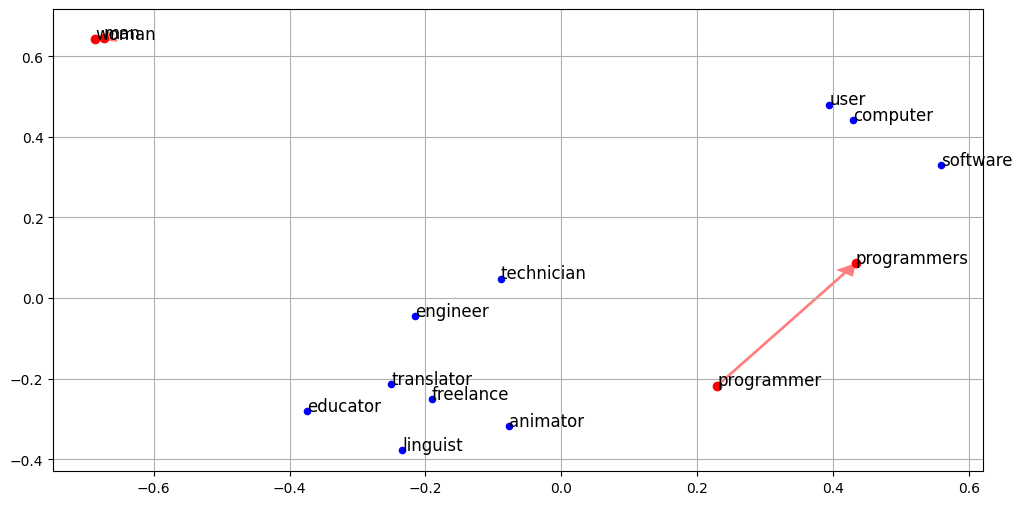

In [15]:
emb.plot_analogy('man', 'woman', 'programmer', n=10)
deb.plot_analogy('man', 'woman', 'programmer', n=10)

In [16]:
deb.analogy("man :: woman -> programmer")
deb.analogy("woman :: man -> programmer")
print(deb.most_similar(deb("programmer"), n=3)[1:])

man :: woman -> programmer :: [programmers]
woman :: man -> programmer :: [programmers]
[np.str_('programmers'), np.str_('software')]


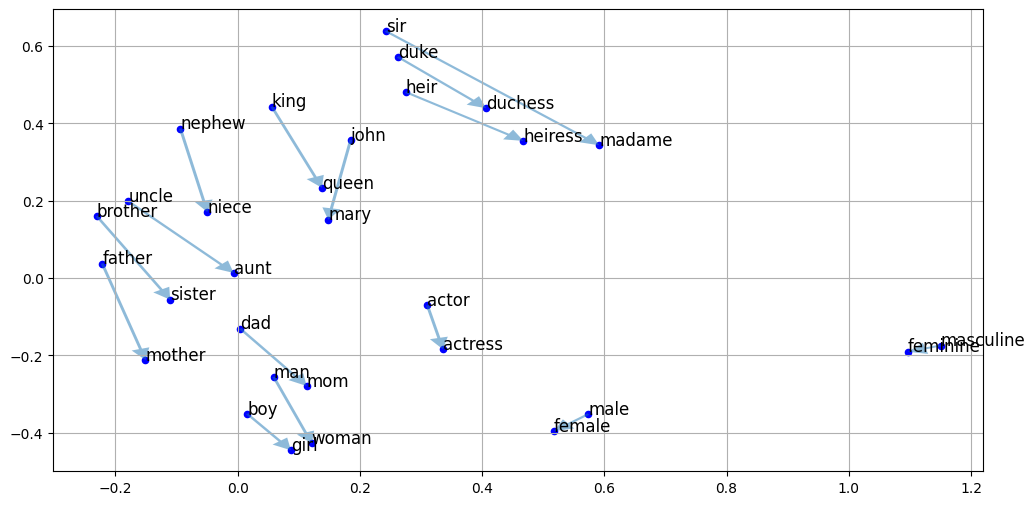

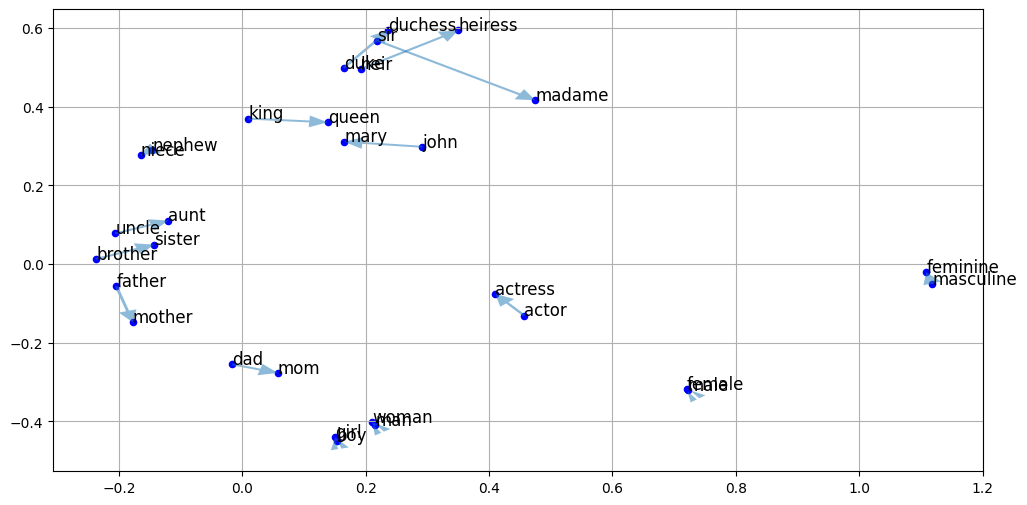

In [17]:
emb.plot_paths(gendered)
deb.plot_paths(gendered)

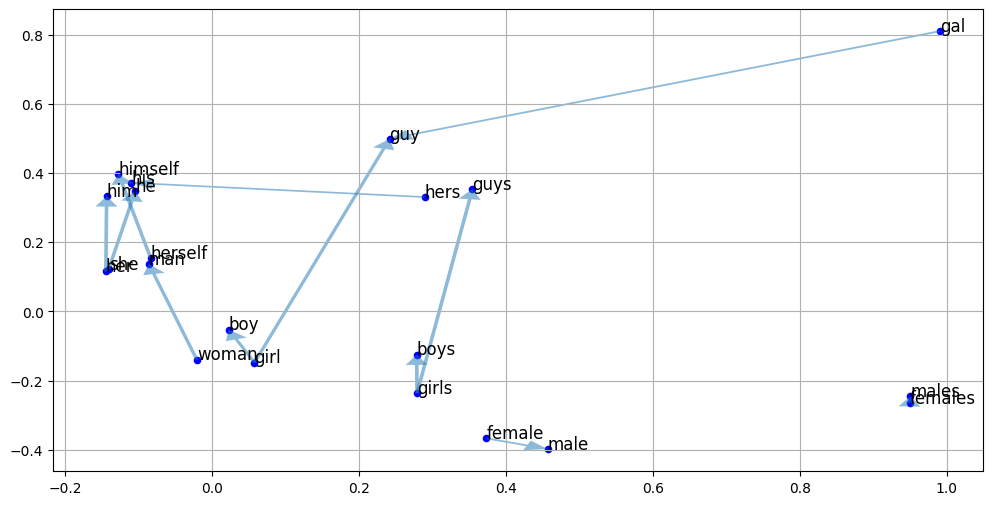

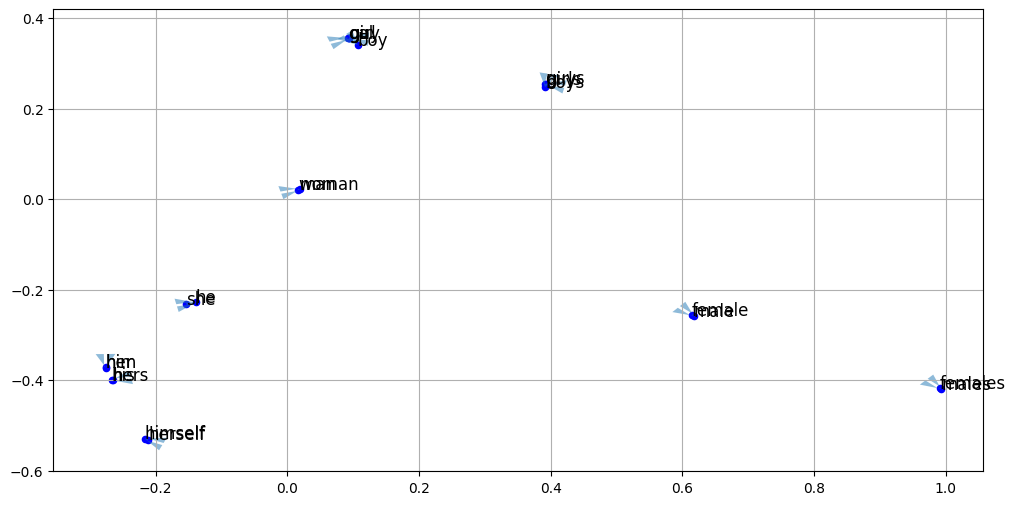

In [18]:
emb.plot_paths(gender_pairs)
deb.plot_paths(gender_pairs)

In [19]:
professions = [
    'caretaker', 'homemaker',
    'doctor', 'nurse', 'programmer', 'teacher',
    'wife', 'husband', 'soldier', 'salesperson', 'analyst', 'therapist',
    'trainer', 'instructor', 'ceo', 'assistant', 'telemarketer',
    'bartender', 'clerk', 'designer', 'father', 'mother', 'scientist',
    'manager', 'boss', 'self-employed', 'employee',
]

In [20]:
sorted(professions, key = lambda w: -norm(deb(w) - emb(w)))

['mother',
 'assistant',
 'manager',
 'boss',
 'father',
 'wife',
 'designer',
 'soldier',
 'nurse',
 'trainer',
 'husband',
 'bartender',
 'salesperson',
 'doctor',
 'homemaker',
 'telemarketer',
 'teacher',
 'clerk',
 'ceo',
 'self-employed',
 'therapist',
 'caretaker',
 'analyst',
 'programmer',
 'scientist',
 'instructor',
 'employee']

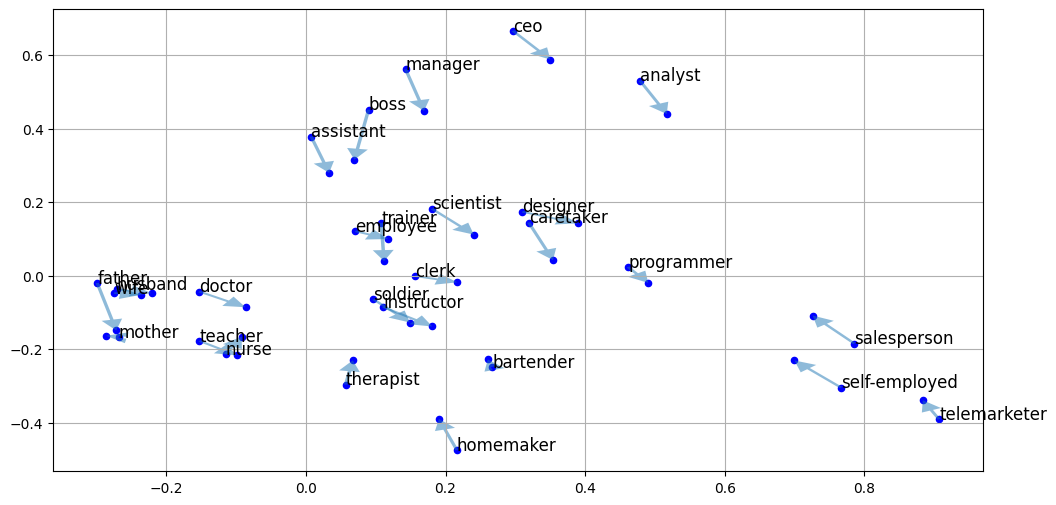

In [21]:
from embedding import plot_change
plot_change(professions, emb, deb)